# 06b — Retrieval Diagnostics

Confronto sistematico delle configurazioni di retrieval (dense, filter, graph, hybrid, LLM rerank, query rewriting) per identificare la configurazione candidata per il notebook `06_advanced_graph_rag.ipynb`.

Tutta la logica vive in `src/legal_rag/retrieval_evaluation/`; questo notebook orchestra il flusso e visualizza le metriche. L'esecuzione è guidata dal **profilo diagnostico** (`light` di default, `full` per la run finale). Override via `RETRIEVAL_DIAGNOSTIC_PROFILE=full`.

Output finale: `scenarios.csv`, `sweep_*.csv`, `manifest.json` e `recommended_advanced_config.json` sotto `data/retrieval_eval_runs/<run_name>__<timestamp>/`.

## 1. Setup e profilo diagnostico

Importa i moduli, carica il profilo attivo e costruisce la `AdvancedRagConfig`, l'embedder cache-aware e il client Qdrant.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "legal_rag").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from legal_rag.advanced_graph_rag import AdvancedRagConfig, RERANK_PROMPT_VERSION
from legal_rag.advanced_graph_rag.retrieval import (
    GraphIndex,
    connect_qdrant,
    dense_vector_name,
    load_index_manifest,
    manifest_disables_sparse,
    resolve_collection_name,
    resolve_qdrant_target,
    sparse_vector_name,
)
from legal_rag.advanced_graph_rag.runner import (
    build_advanced_query_embedder,
    resolve_answer_model,
    resolve_judge_model,
    resolve_utopia_runtime,
    validate_qdrant_collection_ready,
)
from legal_rag.oracle_context_evaluation.env import load_env_file
from legal_rag.oracle_context_evaluation.io import read_jsonl, sha256_file, write_json
from legal_rag.oracle_context_evaluation.llm import (
    OpenAICompatibleStructuredChatClient,
    UtopiaStructuredChatClient,
    resolve_openrouter_runtime,
)
from legal_rag.oracle_context_evaluation.references import OracleReferenceResolver
from legal_rag.retrieval_evaluation import (
    DATASET_SPECS,
    FILTER_VARIANTS,
    QUERY_REWRITING_PROMPT_VERSION,
    RELATION_TYPE_VARIANTS,
    RETRIEVAL_EVALUATION_SCHEMA_VERSION,
    CachedEmbedder,
    ChunkAvailabilityIndex,
    DirectExperimentCache,
    QueryRewriteCache,
    RerankCache,
    best_graph_by_dataset,
    build_query_rewrite_caches,
    build_waterfall,
    default_rerank_cache_path,
    plot_direct_topk_curves,
    plot_filter_comparison,
    plot_graph_topk_configs,
    plot_graph_tradeoff,
    plot_hybrid_sweep,
    plot_query_rewriting_strategies,
    plot_rerank_impact,
    plot_waterfall,
    query_rewriting_failure_rate as qr_failure_rate_fn,
    rerank_best_impact,
    rerank_failure_rate as rerank_failure_rate_fn,
    resolve_profile,
    resolve_question_targets,
    run_direct_experiment,
    run_graph_experiment,
    run_query_rewriting_experiment,
    run_rerank_experiment,
    select_best_scenario,
    select_graph_base_configs,
    summarize_direct,
    summarize_direct_by_level,
    summarize_graph,
    summarize_hybrid,
    summarize_query_rewriting,
    summarize_rerank,
    to_advanced_config_recommendation,
    unique_output_dir,
    write_run_artifacts,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)
plt.rcParams["figure.dpi"] = 90

os.environ["RETRIEVAL_DIAGNOSTIC_PROFILE"] = "full"
os.environ["RETRIEVAL_DIAGNOSTICS_RUN_NAME"] = "diagnostic_full_utopia_throttled"
os.environ["RETRIEVAL_DIAGNOSTICS_LLM_PROVIDER"] = "utopia"
os.environ["RETRIEVAL_DIAGNOSTICS_LLM_TIMEOUT_SECONDS"] = "180"
os.environ["RETRIEVAL_DIAGNOSTICS_MAX_WORKERS"] = "2"
os.environ["RETRIEVAL_DIAGNOSTICS_REQUEST_DELAY_SECONDS"] = "2"

MAX_WORKERS = int(os.environ.get("RETRIEVAL_DIAGNOSTICS_MAX_WORKERS", "1"))
REQUEST_DELAY_SECONDS = float(os.environ.get("RETRIEVAL_DIAGNOSTICS_REQUEST_DELAY_SECONDS", "0"))
profile = resolve_profile()
# Pilot mode override: keep full sweep grids but limit rerank/QR to 30 questions/dataset.
# Tradeoff: small sample for LLM stages, but stable run on flaky Utopia (vs ~6h full run).
profile = profile.model_copy(update={"rerank_full_run": False, "query_rewriting_full_run": False})
RUN_NAME = os.environ.get("RETRIEVAL_DIAGNOSTICS_RUN_NAME") or f"diagnostic_{profile.name}"
OUTPUT_DIR = unique_output_dir(PROJECT_ROOT / "data" / "retrieval_eval_runs", run_name=RUN_NAME)

print(f"Profilo diagnostico: {profile.name} — {profile.description}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Dataset: {profile.datasets}")
print(f"Sweep direct: top_k={profile.top_k_values}, hybrid_top_k={profile.hybrid_top_k_values}, rrf_k={profile.hybrid_rrf_k_values}")
print(f"Esperimenti abilitati: {sorted(profile.enabled_experiments)}")
print(f"LLM provider: {os.environ['RETRIEVAL_DIAGNOSTICS_LLM_PROVIDER']}, max workers: {MAX_WORKERS}, inter-call delay: {REQUEST_DELAY_SECONDS}s, timeout: {os.environ['RETRIEVAL_DIAGNOSTICS_LLM_TIMEOUT_SECONDS']}s")

Profilo diagnostico: full — Run completa che copre i Quality Gates dello spec 06b.
Output dir: /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/retrieval_eval_runs/diagnostic_full_utopia_throttled__20260525T091921Z
Dataset: ['mcq', 'no_hint']
Sweep direct: top_k=[10, 20, 50, 100], hybrid_top_k=[10, 20, 50, 100], rrf_k=[30, 60, 90]
Esperimenti abilitati: ['direct', 'graph', 'hybrid', 'query_rewriting', 'rerank']
LLM provider: utopia, max workers: 2, inter-call delay: 2.0s, timeout: 180s


In [2]:
# Costruisce CONFIG, client Qdrant, embedder cache-aware e LLM factory.
# Tutta la connessione vive qui per non rieseguire il preflight nelle celle dopo.
CONFIG = AdvancedRagConfig(
    evaluation_dir=str(PROJECT_ROOT / "data" / "evaluation_clean"),
    laws_dir=str(PROJECT_ROOT / "data" / "laws_dataset_clean"),
    index_dir=str(PROJECT_ROOT / "data" / "indexes" / "qdrant_server"),
    index_manifest_path=os.environ.get(
        "LEGAL_RAG_INDEX_MANIFEST",
        os.environ.get(
            "RETRIEVAL_DIAGNOSTICS_INDEX_MANIFEST",
            str(PROJECT_ROOT / "data" / "indexing_runs" / "<latest>" / "index_manifest.json"),
        ),
    ),
    collection_name="legal_chunks_bge_m3",
    env_file=str(PROJECT_ROOT / ".env"),
    hybrid_enabled=True,
    graph_expansion_enabled=False,
    rerank_enabled="rerank" in profile.enabled_experiments,
    timeout_seconds=int(os.environ.get("RETRIEVAL_DIAGNOSTICS_LLM_TIMEOUT_SECONDS", "60")),
)

LLM_PROVIDER = (os.environ.get("RETRIEVAL_DIAGNOSTICS_LLM_PROVIDER") or "utopia").strip().lower()
if LLM_PROVIDER not in {"utopia", "openrouter"}:
    raise ValueError("RETRIEVAL_DIAGNOSTICS_LLM_PROVIDER must be 'utopia' or 'openrouter'")


def create_diagnostic_llm_client():
    load_env_file(CONFIG.env_file)
    if LLM_PROVIDER == "openrouter":
        runtime = resolve_openrouter_runtime()
        client = OpenAICompatibleStructuredChatClient(
            api_url=runtime["api_url"],
            api_key=runtime["api_key"],
            retry_attempts=CONFIG.retry_attempts,
            provider_require_parameters=True,
        )
        safe = {k: v for k, v in runtime.items() if k != "api_key"}
        return client, runtime["chat_model"], safe
    runtime = resolve_utopia_runtime(CONFIG)
    answer_model = resolve_answer_model(CONFIG)
    model_name = resolve_judge_model(CONFIG, answer_model)
    client = UtopiaStructuredChatClient(
        api_url=runtime["api_url"],
        api_key=runtime["api_key"],
        retry_attempts=CONFIG.retry_attempts,
    )
    safe = {k: v for k, v in runtime.items() if k != "api_key"}
    return client, model_name, safe


index_manifest_path, index_manifest = load_index_manifest(CONFIG)
collection_name = resolve_collection_name(CONFIG, index_manifest)
qdrant_client = connect_qdrant(CONFIG, index_manifest)
qdrant_target = resolve_qdrant_target(CONFIG, index_manifest)
validate_qdrant_collection_ready(
    qdrant_client=qdrant_client,
    collection_name=collection_name,
    qdrant_target=qdrant_target,
)
base_embedder = build_advanced_query_embedder(CONFIG, index_manifest)
embedder = CachedEmbedder(base_embedder)

dense_available = dense_vector_name(qdrant_client, collection_name=collection_name) is not None
hybrid_available = (
    sparse_vector_name(qdrant_client, collection_name=collection_name) is not None
    and not manifest_disables_sparse(index_manifest)
    and (
        callable(getattr(base_embedder, "embed_sparse_texts", None))
        or callable(getattr(base_embedder, "sparse_embed_texts", None))
    )
)
retrieval_modes = ["dense"] + (["hybrid"] if hybrid_available else [])
print(f"Collection: {collection_name}; dense_available={dense_available}; hybrid_available={hybrid_available}")

Fetching 30 files:   0%|          | 0/30 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Collection: legal_chunks_bge_m3; dense_available=True; hybrid_available=True


## 2. Preflight: dataset, ground truth e cache condivisa

Carica i dataset di valutazione del profilo attivo, risolve gli expected references e prepara la cache di retrieval condivisa tra esperimenti.

In [3]:
# Filtra DATASET_SPECS sui dataset effettivamente attivi nel profilo.
dataset_specs = {name: DATASET_SPECS[name] for name in profile.datasets if name in DATASET_SPECS}
records_by_dataset = {
    name: read_jsonl(Path(CONFIG.evaluation_dir) / spec["filename"])
    for name, spec in dataset_specs.items()
}
if profile.benchmark_size is not None:
    records_by_dataset = {name: rs[: profile.benchmark_size] for name, rs in records_by_dataset.items()}

resolver = OracleReferenceResolver.from_dir(CONFIG.laws_dir)
chunks = read_jsonl(Path(CONFIG.laws_dir) / "chunks.jsonl")
availability = ChunkAvailabilityIndex(chunks)
graph = GraphIndex.from_dir(CONFIG.laws_dir)

targets_by_dataset = {
    name: resolve_question_targets(
        records,
        resolver=resolver,
        availability=availability,
        question_key=dataset_specs[name]["question_key"],
    )
    for name, records in records_by_dataset.items()
}

# Prewarm embedding cache so the actual sweep is dominated by Qdrant lookups, not embedder I/O.
if os.environ.get("RETRIEVAL_DIAGNOSTICS_PREWARM", "1") != "0":
    all_questions = [t.question for targets in targets_by_dataset.values() for t in targets]
    embedder.embed_texts(all_questions)
    print(f"Embedding prewarm OK ({len(all_questions)} query)")

cache = DirectExperimentCache()
display(pd.DataFrame([
    {"dataset": name, "questions": len(targets), "expected_articles_avg": round(
        sum(len(t.expected_article_ids) for t in targets) / max(1, len(targets)), 2,
    )}
    for name, targets in targets_by_dataset.items()
]))

Embedding prewarm OK (200 query)


,dataset,questions,expected_articles_avg
0,mcq,100,1.06
1,no_hint,100,1.06


## Esperimento A — Baseline dense e curva top-k

Sweep dense e hybrid (quando disponibile) su tutti i `top_k` del profilo, con filtro `none`. È la base da cui derivano tutti gli altri esperimenti.

In [4]:
# Run del sweep direct (dense + hybrid). Il cache shared è popolato per i successivi esperimenti.
direct_df = run_direct_experiment(
    targets_by_dataset=targets_by_dataset,
    cache=cache,
    qdrant_client=qdrant_client,
    collection_name=collection_name,
    embedder=embedder,
    index_manifest=index_manifest,
    rrf_k_default=CONFIG.rrf_k,
    availability=availability,
    modes=retrieval_modes,
    filter_names=profile.filter_variants,
    filter_variants=FILTER_VARIANTS,
    top_k_values=profile.top_k_values,
    hybrid_top_k_values=profile.hybrid_top_k_values,
    hybrid_rrf_k_values=profile.hybrid_rrf_k_values,
    max_workers=MAX_WORKERS,
)
direct_summary = summarize_direct(direct_df)
direct_level_summary = summarize_direct_by_level(direct_df)

print(f"Direct rows: {len(direct_df)}  |  embedding cache dense={embedder.dense_cache_size}, sparse={embedder.sparse_cache_size}")
display(Markdown("**Baseline dense (filter=none)**"))
display(direct_summary[(direct_summary["retrieval_mode"] == "dense") & (direct_summary["filter_name"] == "none")])

direct experiments:   0%|          | 0/5600 [00:00<?, ?it/s]

Direct rows: 5600  |  embedding cache dense=100, sparse=100


**Baseline dense (filter=none)**

,dataset,retrieval_mode,filter_name,top_k,rrf_k,questions,article_hit,all_expected_articles_hit,law_hit,article_mrr,law_only_false_positive_rate,filter_excluded_rate,avg_best_answer_overlap
12,mcq,dense,none,10,NaN,100,0.73,0.71,0.97,0.518806,0.24,0.0,0.111672
13,mcq,dense,none,20,NaN,100,0.77,0.75,0.97,0.521130,0.20,0.0,0.120416
14,mcq,dense,none,50,NaN,100,0.84,0.82,0.97,0.523206,0.13,0.0,0.137547
15,mcq,dense,none,100,NaN,100,0.88,0.87,0.99,0.523918,0.11,0.0,0.148137
40,no_hint,dense,none,10,NaN,100,0.73,0.71,0.97,0.518806,0.24,0.0,0.111672
41,no_hint,dense,none,20,NaN,100,0.77,0.75,0.97,0.521130,0.20,0.0,0.120416
42,no_hint,dense,none,50,NaN,100,0.84,0.82,0.97,0.523206,0.13,0.0,0.137547
43,no_hint,dense,none,100,NaN,100,0.88,0.87,0.99,0.523918,0.11,0.0,0.148137


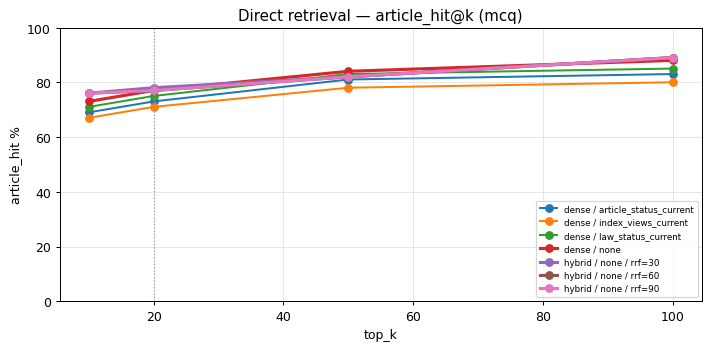

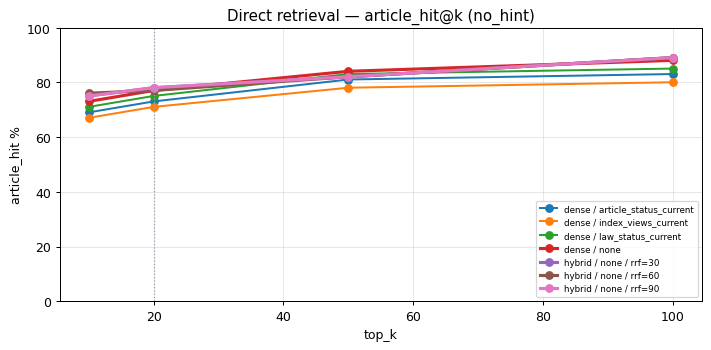

In [5]:
# Visualizzazione esperimento A — una curva per dataset.
for dataset in dataset_specs:
    plot_direct_topk_curves(direct_summary, dataset=dataset, budget_top_k=profile.budget_top_k)
    plt.show()

## Esperimento B — Filtri metadata

Confronta i filtri (`law_status=current`, ecc.) sul baseline dense per misurare quanto incidono su article_hit e quanti articoli attesi vengono esclusi.

In [6]:
# Riusa direct_df: il sweep filter è già incluso nel direct experiment.
filter_summary = direct_summary[direct_summary["retrieval_mode"] == "dense"].copy()
display(Markdown("**Sweep dense per filtro, top_k profilo**"))
display(filter_summary.sort_values(["dataset", "top_k", "article_hit"], ascending=[True, True, False]))

**Sweep dense per filtro, top_k profilo**

,dataset,retrieval_mode,filter_name,top_k,rrf_k,questions,article_hit,all_expected_articles_hit,law_hit,article_mrr,law_only_false_positive_rate,filter_excluded_rate,avg_best_answer_overlap
12,mcq,dense,none,10,NaN,100,0.73,0.71,0.97,0.518806,0.24,0.00,0.111672
8,mcq,dense,law_status_current,10,NaN,100,0.71,0.69,0.93,0.507139,0.22,0.04,0.113128
0,mcq,dense,article_status_current,10,NaN,100,0.69,0.67,0.93,0.503083,0.24,0.06,0.106206
4,mcq,dense,index_views_current,10,NaN,100,0.67,0.65,0.89,0.491417,0.22,0.10,0.107585
13,mcq,dense,none,20,NaN,100,0.77,0.75,0.97,0.521130,0.20,0.00,0.120416
9,mcq,dense,law_status_current,20,NaN,100,0.75,0.73,0.93,0.509464,0.18,0.04,0.124884
1,mcq,dense,article_status_current,20,NaN,100,0.73,0.71,0.95,0.505636,0.22,0.06,0.120110
5,mcq,dense,index_views_current,20,NaN,100,0.71,0.69,0.91,0.493970,0.20,0.10,0.121803
14,mcq,dense,none,50,NaN,100,0.84,0.82,0.97,0.523206,0.13,0.00,0.137547
10,mcq,dense,law_status_current,50,NaN,100,0.83,0.81,0.93,0.511770,0.10,0.04,0.138205


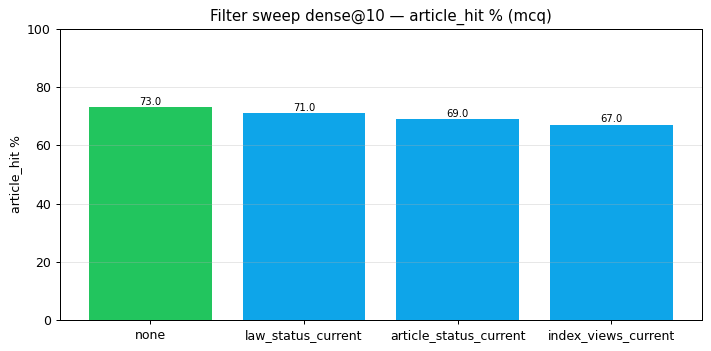

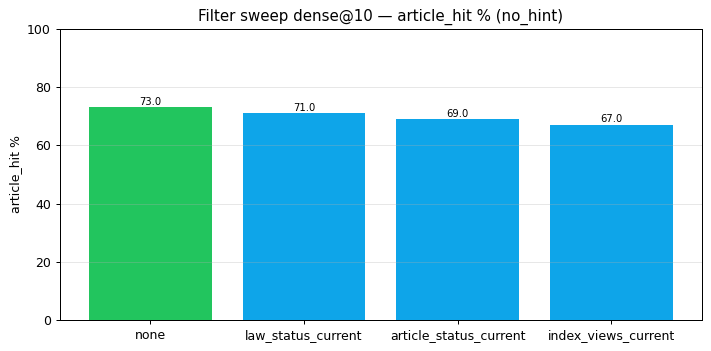

In [7]:
# Visualizzazione esperimento B — bar plot dei filtri a baseline_top_k per dataset.
for dataset in dataset_specs:
    plot_filter_comparison(direct_summary, dataset=dataset, top_k=profile.baseline_top_k)
    plt.show()

## Esperimento C — Graph expansion

Espande la candidate list attraverso il grafo legale partendo dai base config selezionati dal sweep dense/hybrid. Misura `post_article_hit`, `delta_vs_direct` e `expansion_noise_ratio` per ogni configurazione.

In [8]:
# Esegue il sweep graph solo se abilitato dal profilo.
graph_enabled = "graph" in profile.enabled_experiments
if graph_enabled:
    base_configs = select_graph_base_configs(
        direct_summary,
        datasets=list(dataset_specs),
        base_config_names=profile.graph_base_configs,
        baseline_top_k=profile.baseline_top_k,
    )
    graph_df = run_graph_experiment(
        targets_by_dataset=targets_by_dataset,
        base_configs=base_configs,
        cache=cache,
        qdrant_client=qdrant_client,
        collection_name=collection_name,
        embedder=embedder,
        index_manifest=index_manifest,
        rrf_k_default=CONFIG.rrf_k,
        graph=graph,
        availability=availability,
        filter_variants=FILTER_VARIANTS,
        relation_type_variants=RELATION_TYPE_VARIANTS,
        seed_k_values=profile.graph_seed_k_values,
        max_chunks_per_law_values=profile.graph_max_chunks_per_law_values,
        min_edge_confidence_values=profile.graph_min_edge_confidence_values,
        relation_set_names=profile.graph_relation_set_names,
        max_expanded_chunks_total=CONFIG.max_expanded_chunks_total,
        expand_only_problem_cases=profile.graph_expand_only_problem_cases,
        backend=os.environ.get("RETRIEVAL_DIAGNOSTICS_GRAPH_BACKEND", "qdrant_ranked"),
    )
    graph_summary = summarize_graph(graph_df)
    best_graph_df = best_graph_by_dataset(graph_summary)
    print(f"Graph rows: {len(graph_df)}; base configs selezionate: {len(base_configs)}")
    display(graph_summary.head(15))
else:
    graph_df = pd.DataFrame()
    graph_summary = pd.DataFrame()
    best_graph_df = pd.DataFrame()
    print("Graph sweep disabilitato dal profilo.")

graph experiments:   0%|          | 0/3200 [00:00<?, ?it/s]

Graph rows: 3200; base configs selezionate: 4


,dataset,graph_base_config_name,retrieval_mode,filter_name,top_k,rrf_k,graph_expansion_seed_k,max_chunks_per_expanded_law,min_edge_confidence,relation_set_name,questions,expansion_attempt_rate,direct_article_hit,post_article_hit,post_law_hit,post_article_mrr,graph_incremental_hits,expanded_expected_article_hits,expansion_noise_ratio,filter_excluded_rate,delta_vs_direct
3,mcq,dense@10,dense,none,10,NaN,1,2,0.45,references_only,100,0.27,0.73,0.74,0.97,0.519575,1,1,0.997143,0.0,0.01
2,mcq,dense@10,dense,none,10,NaN,1,2,0.45,default,100,0.27,0.73,0.74,0.97,0.519332,1,1,0.997333,0.0,0.01
6,mcq,dense@10,dense,none,10,NaN,3,2,0.45,default,100,0.27,0.73,0.74,0.97,0.519332,1,1,0.997436,0.0,0.01
7,mcq,dense@10,dense,none,10,NaN,3,2,0.45,references_only,100,0.27,0.73,0.74,0.97,0.519575,1,1,0.997436,0.0,0.01
8,mcq,hybrid_best,hybrid,none,100,30.0,1,1,0.45,default,100,0.11,0.89,0.89,0.99,0.551039,0,0,1.000000,0.0,0.00
9,mcq,hybrid_best,hybrid,none,100,30.0,1,1,0.45,references_only,100,0.11,0.89,0.89,0.99,0.551039,0,0,1.000000,0.0,0.00
10,mcq,hybrid_best,hybrid,none,100,30.0,1,2,0.45,default,100,0.11,0.89,0.89,0.99,0.551039,0,0,1.000000,0.0,0.00
11,mcq,hybrid_best,hybrid,none,100,30.0,1,2,0.45,references_only,100,0.11,0.89,0.89,0.99,0.551039,0,0,1.000000,0.0,0.00
12,mcq,hybrid_best,hybrid,none,100,30.0,3,1,0.45,default,100,0.11,0.89,0.89,0.99,0.551039,0,0,1.000000,0.0,0.00
13,mcq,hybrid_best,hybrid,none,100,30.0,3,1,0.45,references_only,100,0.11,0.89,0.89,0.99,0.551039,0,0,1.000000,0.0,0.00


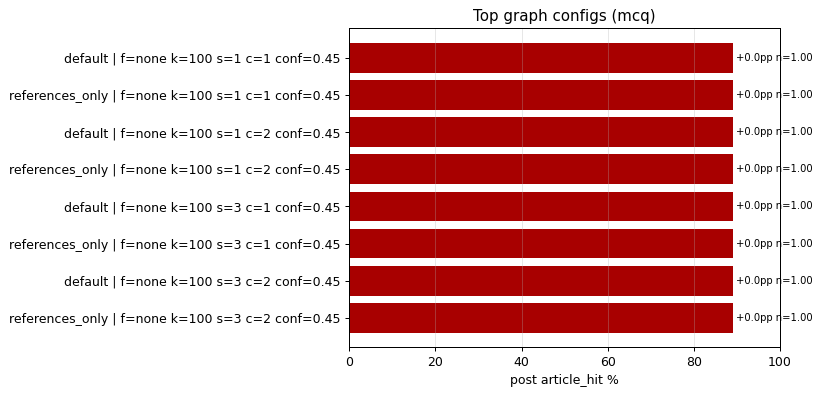

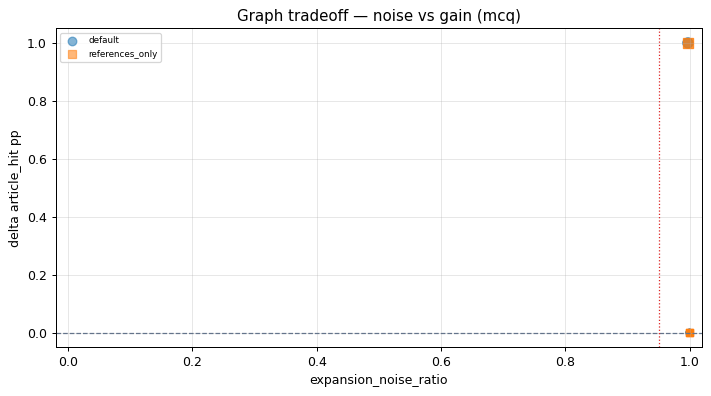

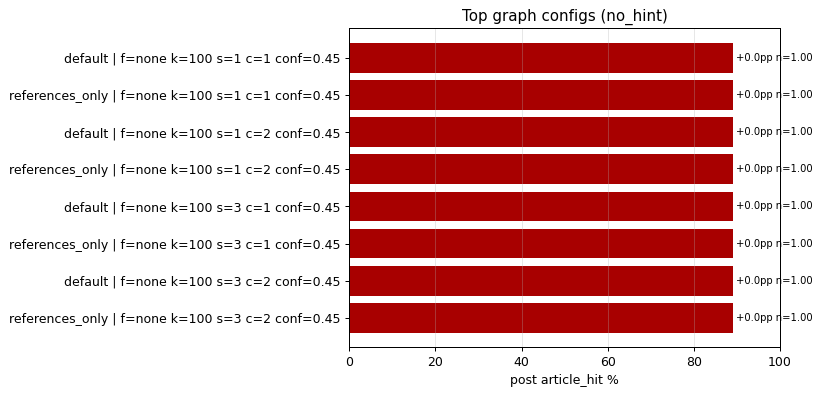

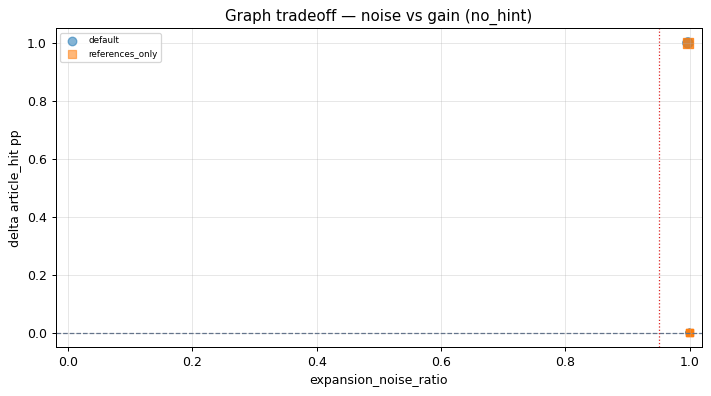

In [9]:
# Visualizzazione esperimento C — top configs + tradeoff hit vs noise per dataset.
if not graph_summary.empty:
    for dataset in dataset_specs:
        plot_graph_topk_configs(graph_summary, dataset=dataset)
        plt.show()
        plot_graph_tradeoff(graph_summary, dataset=dataset, low_noise_threshold=profile.low_noise_threshold)
        plt.show()

## Esperimento F — Hybrid retrieval

Confronto dense vs hybrid (RRF) sulla stessa griglia top_k. Vista filtrata del direct sweep limitata ai due modi.

In [10]:
# Subset di direct_summary su dense + hybrid (lo sweep è già eseguito sopra).
hybrid_summary = summarize_hybrid(direct_summary)
if hybrid_summary.empty or "hybrid" not in retrieval_modes:
    print("Hybrid retrieval non disponibile per questo indice.")
else:
    display(Markdown("**Dense vs Hybrid — sweep top_k / rrf_k**"))
    display(hybrid_summary.sort_values(["dataset", "article_hit"], ascending=[True, False]).head(20))

**Dense vs Hybrid — sweep top_k / rrf_k**

,dataset,retrieval_mode,filter_name,top_k,rrf_k,questions,article_hit,all_expected_articles_hit,law_hit,article_mrr,law_only_false_positive_rate,filter_excluded_rate,avg_best_answer_overlap
25,mcq,hybrid,none,100,30.0,100,0.89,0.88,0.99,0.551039,0.10,0.00,0.149045
26,mcq,hybrid,none,100,60.0,100,0.89,0.88,0.99,0.546564,0.10,0.00,0.149045
27,mcq,hybrid,none,100,90.0,100,0.89,0.88,0.99,0.544607,0.10,0.00,0.149045
15,mcq,dense,none,100,NaN,100,0.88,0.87,0.99,0.523918,0.11,0.00,0.148137
11,mcq,dense,law_status_current,100,NaN,100,0.85,0.84,0.95,0.512107,0.10,0.04,0.151953
14,mcq,dense,none,50,NaN,100,0.84,0.82,0.97,0.523206,0.13,0.00,0.137547
3,mcq,dense,article_status_current,100,NaN,100,0.83,0.82,0.99,0.508424,0.16,0.06,0.146829
10,mcq,dense,law_status_current,50,NaN,100,0.83,0.81,0.93,0.511770,0.10,0.04,0.138205
22,mcq,hybrid,none,50,30.0,100,0.82,0.81,0.98,0.542191,0.16,0.00,0.131176
23,mcq,hybrid,none,50,60.0,100,0.82,0.81,0.98,0.549786,0.16,0.00,0.131176


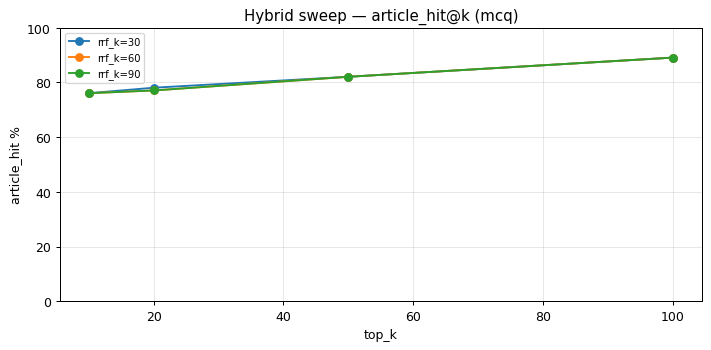

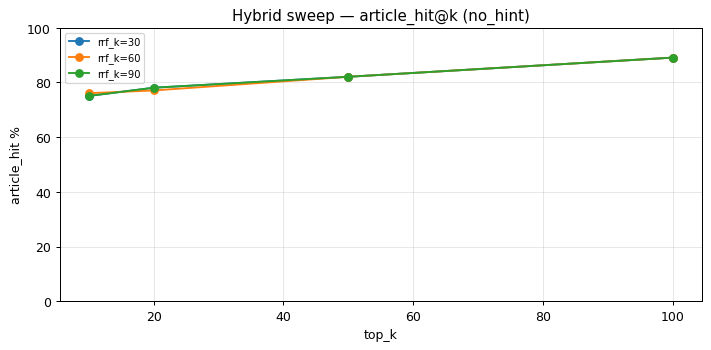

In [11]:
# Visualizzazione esperimento F — line plot per rrf_k.
if hybrid_available:
    for dataset in dataset_specs:
        plot_hybrid_sweep(direct_summary, dataset=dataset)
        plt.show()

## Esperimento G — LLM Reranking (pilot)

Pilot deterministico di 30 domande (configurabile via profilo) sul best hybrid. Cache LLM versionata con `RERANK_PROMPT_VERSION`.

In [12]:
# Esegue rerank solo se profilo + hybrid lo consentono.
rerank_enabled = "rerank" in profile.enabled_experiments and hybrid_available
rerank_df = pd.DataFrame()
rerank_summary = pd.DataFrame()
rerank_impact_df = pd.DataFrame()
rerank_failures: list[dict] = []
rerank_stats: dict[str, int] = {"cache_hits": 0, "cache_misses": 0, "failures": 0, "rows": 0}
rerank_model_name: str | None = None
rerank_cache_file: Path | None = None

if rerank_enabled:
    llm_client, rerank_model_name, _ = create_diagnostic_llm_client()
    rerank_cache_file = default_rerank_cache_path(PROJECT_ROOT / "data" / "cache", model=rerank_model_name)
    rerank_cache = RerankCache(rerank_cache_file)
    rerank_df, rerank_failures, rerank_stats = run_rerank_experiment(
        targets_by_dataset=targets_by_dataset,
        direct_summary_df=direct_summary,
        cache=cache,
        rerank_cache=rerank_cache,
        qdrant_client=qdrant_client,
        collection_name=collection_name,
        embedder=embedder,
        index_manifest=index_manifest,
        rrf_k_default=CONFIG.rrf_k,
        llm_client=llm_client,
        rerank_model=rerank_model_name,
        timeout_seconds=CONFIG.timeout_seconds,
        input_k_values=profile.rerank_input_k_values,
        output_k_values=profile.rerank_output_k_values,
        question_sample=profile.rerank_question_sample,
        sample_seed=profile.rerank_sample_seed,
        full_run=profile.rerank_full_run,
        max_workers=MAX_WORKERS,
        request_delay_seconds=REQUEST_DELAY_SECONDS,
    )
    rerank_summary = summarize_rerank(rerank_df)
    rerank_impact_df = rerank_best_impact(rerank_summary)
    print(f"Rerank: rows={rerank_stats['rows']} cache_hits={rerank_stats['cache_hits']} cache_misses={rerank_stats['cache_misses']} failures={rerank_stats['failures']}")
    display(rerank_summary)
else:
    print("Rerank disabilitato dal profilo o hybrid non disponibile.")

rerank calls:   0%|          | 0/180 [00:00<?, ?it/s]

Rerank: rows=375 cache_hits=10 cache_misses=115 failures=55


,dataset,retrieval_mode,top_k,rrf_k,rerank_input_k,rerank_output_k,rerank_model,questions,article_hit,law_hit,article_mrr,pre_article_hit,cache_hit_rate,recovered,demoted,delta_vs_pre_article_hit,net_recovered
0,mcq,hybrid,20,30,20,3,SLURM.gpt-oss:120b,23,0.739130,0.869565,0.695652,0.826087,0.173913,0,2,-0.086957,-2
1,mcq,hybrid,20,30,20,5,SLURM.gpt-oss:120b,23,0.782609,0.956522,0.704348,0.826087,0.173913,0,1,-0.043478,-1
2,mcq,hybrid,20,30,20,10,SLURM.gpt-oss:120b,23,0.826087,1.000000,0.710559,0.826087,0.173913,0,0,0.000000,0
3,mcq,hybrid,50,30,50,3,SLURM.gpt-oss:120b,24,0.708333,0.833333,0.645833,0.833333,0.000000,0,3,-0.125000,-3
4,mcq,hybrid,50,30,50,5,SLURM.gpt-oss:120b,24,0.708333,0.875000,0.645833,0.833333,0.000000,0,3,-0.125000,-3
5,mcq,hybrid,50,30,50,10,SLURM.gpt-oss:120b,24,0.750000,0.958333,0.652778,0.833333,0.000000,0,2,-0.083333,-2
6,mcq,hybrid,100,30,100,3,SLURM.gpt-oss:120b,20,0.700000,0.900000,0.616667,0.900000,0.000000,0,4,-0.200000,-4
7,mcq,hybrid,100,30,100,5,SLURM.gpt-oss:120b,20,0.750000,0.950000,0.626667,0.900000,0.000000,0,3,-0.150000,-3
8,mcq,hybrid,100,30,100,10,SLURM.gpt-oss:120b,20,0.800000,0.950000,0.635000,0.900000,0.000000,0,2,-0.100000,-2
9,no_hint,hybrid,20,30,20,3,SLURM.gpt-oss:120b,22,0.727273,0.863636,0.674242,0.772727,0.227273,0,1,-0.045455,-1


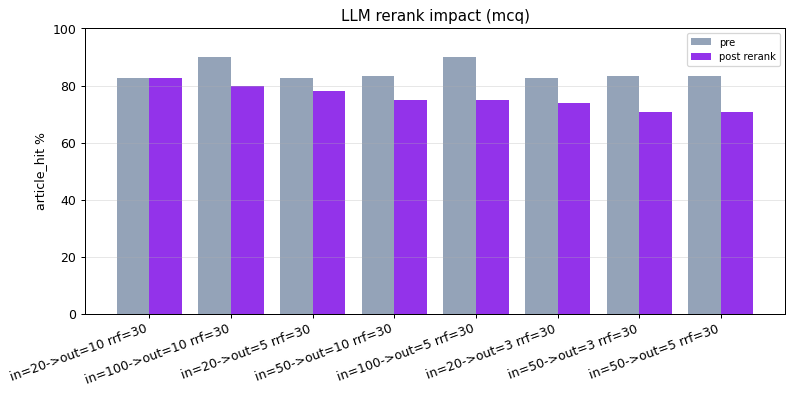

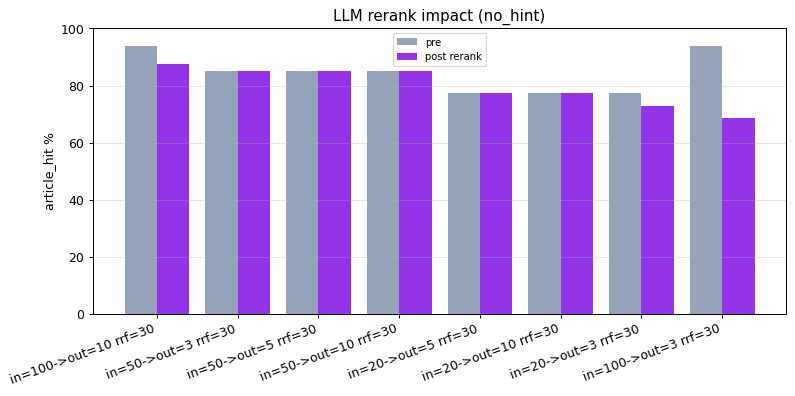

In [13]:
# Visualizzazione esperimento G — pre vs post rerank per le top configurazioni.
if not rerank_summary.empty:
    for dataset in dataset_specs:
        plot_rerank_impact(rerank_summary, dataset=dataset)
        plt.show()

## Esperimento H — Query rewriting / HyDE / multi-query

Pilot deterministico di 30 domande × 4 strategie sul best hybrid. Cache versionata per `(strategy, model, prompt_version)`.

In [14]:
# Esegue query rewriting solo se profilo + hybrid lo consentono.
qr_enabled = "query_rewriting" in profile.enabled_experiments and hybrid_available
query_rewrite_df = pd.DataFrame()
query_rewrite_summary = pd.DataFrame()
query_rewrite_failures: list[dict] = []
query_rewrite_examples: list[dict] = []
query_rewrite_stats: dict[str, int] = {"cache_hits": 0, "cache_misses": 0, "failures": 0, "rows": 0}
query_rewrite_model_name: str | None = None
query_rewrite_cache_files: dict[str, Path] = {}

if qr_enabled:
    llm_client, query_rewrite_model_name, _ = create_diagnostic_llm_client()
    rewrite_caches = build_query_rewrite_caches(
        strategies=profile.query_rewriting_strategies,
        cache_root=PROJECT_ROOT / "data" / "cache",
        model=query_rewrite_model_name,
    )
    query_rewrite_cache_files = {strategy: cache_obj.path for strategy, cache_obj in rewrite_caches.items()}
    query_rewrite_df, query_rewrite_failures, query_rewrite_examples, query_rewrite_stats = run_query_rewriting_experiment(
        targets_by_dataset=targets_by_dataset,
        direct_summary_df=direct_summary,
        qdrant_client=qdrant_client,
        collection_name=collection_name,
        embedder=embedder,
        index_manifest=index_manifest,
        llm_client=llm_client,
        rewrite_caches=rewrite_caches,
        rewrite_model=query_rewrite_model_name,
        timeout_seconds=CONFIG.timeout_seconds,
        strategies=profile.query_rewriting_strategies,
        question_sample=profile.query_rewriting_question_sample,
        sample_seed=profile.query_rewriting_sample_seed,
        multi_query_n=profile.multi_query_n,
        full_run=profile.query_rewriting_full_run,
        max_workers=MAX_WORKERS,
        request_delay_seconds=REQUEST_DELAY_SECONDS,
    )
    query_rewrite_summary = summarize_query_rewriting(query_rewrite_df)
    print(f"Query rewriting: rows={query_rewrite_stats['rows']} cache_hits={query_rewrite_stats['cache_hits']} cache_misses={query_rewrite_stats['cache_misses']} failures={query_rewrite_stats['failures']}")
    display(query_rewrite_summary)
    if query_rewrite_examples:
        display(Markdown("**Esempi qualitativi**"))
        display(pd.DataFrame(query_rewrite_examples))
else:
    print("Query rewriting disabilitato dal profilo o hybrid non disponibile.")

query rewriting calls:   0%|          | 0/240 [00:00<?, ?it/s]

Query rewriting: rows=240 cache_hits=180 cache_misses=0 failures=0


,dataset,strategy,retrieval_mode,top_k,rrf_k,questions,article_hit,law_hit,article_mrr,cache_hit_rate,avg_transformed_queries
1,mcq,multi_query,hybrid,100,30,30,0.933333,1.000000,0.467492,1.0,3.0
3,mcq,rewrite,hybrid,100,30,30,0.900000,0.966667,0.525208,1.0,1.0
0,mcq,hyde,hybrid,100,30,30,0.866667,0.966667,0.471201,1.0,1.0
2,mcq,none,hybrid,100,30,30,0.833333,0.966667,0.492719,1.0,1.0
5,no_hint,multi_query,hybrid,100,30,30,0.933333,1.000000,0.484148,1.0,3.0
7,no_hint,rewrite,hybrid,100,30,30,0.900000,0.966667,0.508538,1.0,1.0
4,no_hint,hyde,hybrid,100,30,30,0.866667,0.966667,0.437755,1.0,1.0
6,no_hint,none,hybrid,100,30,30,0.833333,0.966667,0.459545,1.0,1.0


**Esempi qualitativi**

,dataset,qid,strategy,question,transformed_queries
0,mcq,eval-0005,rewrite,Da quanti membri è composta la Consulta regionale per la mobilità ciclistica?,[numero di membri della Consulta regionale per la mobilità ciclistica]
1,mcq,eval-0005,hyde,Da quanti membri è composta la Consulta regionale per la mobilità ciclistica?,"[La Consulta regionale per la mobilità ciclistica è composta da dieci membri, nominati tra esperti, rappresentanti delle associazioni ci..."
2,mcq,eval-0005,multi_query,Da quanti membri è composta la Consulta regionale per la mobilità ciclistica?,"[Qual è il numero dei componenti della Consulta regionale per la mobilità ciclistica?, Quanti membri compongono la Consulta regionale pe..."


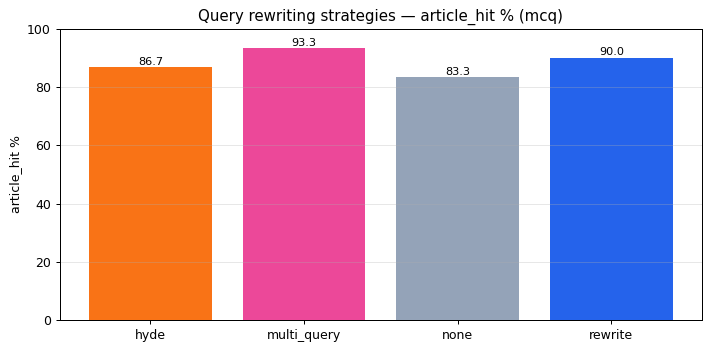

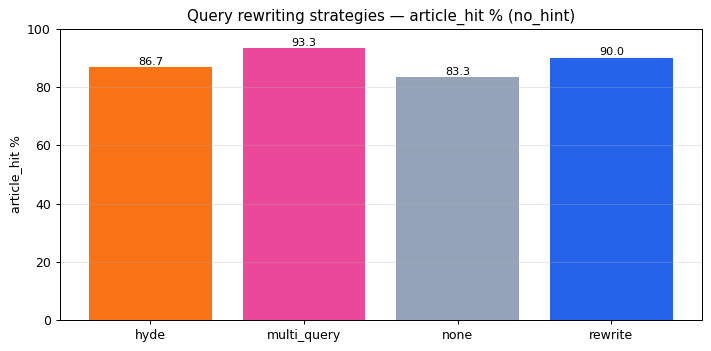

In [15]:
# Visualizzazione esperimento H — bar plot delle strategie.
if not query_rewrite_summary.empty:
    for dataset in dataset_specs:
        plot_query_rewriting_strategies(query_rewrite_summary, dataset=dataset)
        plt.show()

## Waterfall finale

Aggrega tutti gli esperimenti in `scenarios.csv`, calcola il vincitore per dataset e visualizza la classifica.

In [16]:
scenarios_df = build_waterfall(
    datasets=list(dataset_specs),
    profile=profile,
    direct_df=direct_df,
    direct_summary_df=direct_summary,
    graph_df=graph_df,
    graph_summary_df=graph_summary,
    best_graph_by_dataset_df=best_graph_df,
    rerank_df=rerank_df,
    query_rewrite_df=query_rewrite_df,
    hybrid_available=hybrid_available,
    graph_enabled=graph_enabled,
    rerank_enabled=rerank_enabled,
    query_rewriting_enabled=qr_enabled,
)
display(scenarios_df[[
    "experiment_name", "scenario_name", "dataset", "stage", "status",
    "article_hit_pct", "law_hit_pct", "article_mrr", "delta_vs_baseline", "skip_reason",
]])

,experiment_name,scenario_name,dataset,stage,status,article_hit_pct,law_hit_pct,article_mrr,delta_vs_baseline,skip_reason
0,dense_baseline_top10,Baseline dense@10 (no filter),mcq,direct,run,73.000000,97.00,0.518806,NaN,
1,dense_topk_curve,Best dense top-k (no filter),mcq,direct,run,88.000000,99.00,0.523918,15.000000,
2,best_dense_budget_top20,Best direct budget top20,mcq,direct,run,77.000000,97.00,0.521130,4.000000,
3,current_law_filter,+ Filter law_status=current,mcq,direct,run,71.000000,93.00,0.507139,-2.000000,
4,best_filter_from_sweep,+ Best filter from sweep,mcq,direct,run,73.000000,97.00,0.518806,0.000000,
5,graph_default_seed3,+ Graph default seed=3,mcq,graph,run,74.000000,97.00,0.519332,1.000000,
6,graph_references_only,+ Graph REFERENCES only,mcq,graph,run,74.000000,97.00,0.519575,1.000000,
7,best_graph_from_sweep,+ Best graph from sweep,mcq,graph,run,74.000000,97.00,0.519575,1.000000,
8,best_graph_low_noise,+ Best graph low-noise skipped,mcq,graph,skipped,NaN,NaN,NaN,NaN,No graph configuration with expansion_noise_ratio <= 0.95
9,hybrid_if_available,Hybrid best available,mcq,direct,run,89.000000,99.00,0.551039,16.000000,


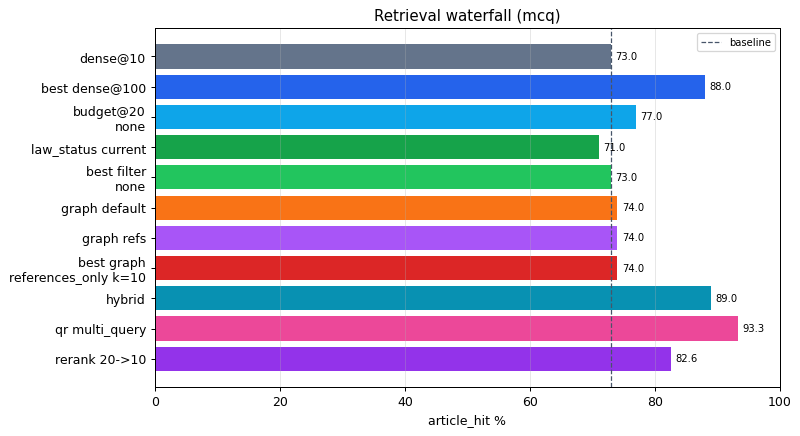

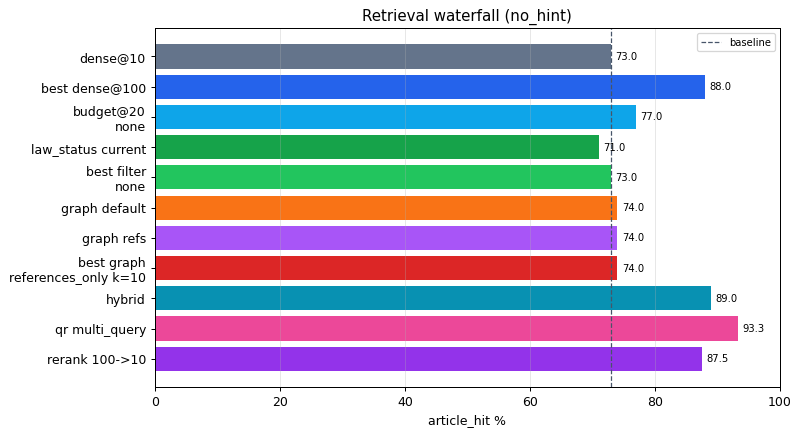

**Vincitore per dataset**

,dataset,winner_experiment,scenario_name,article_hit_pct,article_mrr,delta_vs_baseline
0,mcq,query_rewriting,+ Query rewriting,93.333333,0.467492,20.333333
1,no_hint,query_rewriting,+ Query rewriting,93.333333,0.484148,20.333333


In [17]:
# Plot waterfall e identificazione del vincitore per dataset.
winner_rows = []
for dataset in dataset_specs:
    plot_waterfall(scenarios_df, dataset=dataset)
    plt.show()
    winner = select_best_scenario(scenarios_df, dataset=dataset)
    if winner is not None:
        winner_rows.append({
            "dataset": dataset,
            "winner_experiment": winner["experiment_name"],
            "scenario_name": winner["scenario_name"],
            "article_hit_pct": float(winner["article_hit_pct"]),
            "article_mrr": float(winner["article_mrr"]),
            "delta_vs_baseline": float(winner["delta_vs_baseline"] or 0.0),
        })
if winner_rows:
    display(Markdown("**Vincitore per dataset**"))
    display(pd.DataFrame(winner_rows))

## Raccomandazione per il notebook 06

Traduce il vincitore in un payload `recommended_advanced_config.json` consumato da `06_advanced_graph_rag.ipynb`.

In [18]:
rerank_fr = rerank_failure_rate_fn(rerank_failures, cache_stats=rerank_stats) if rerank_enabled else 0.0
qr_fr = qr_failure_rate_fn(query_rewrite_failures, cache_stats=query_rewrite_stats) if qr_enabled else 0.0

advanced_rag_defaults = {
    "top_k": CONFIG.top_k,
    "rrf_k": CONFIG.rrf_k,
    "graph_expansion_seed_k": CONFIG.graph_expansion_seed_k,
    "graph_expansion_relation_types": CONFIG.graph_expansion_relation_types,
    "max_chunks_per_expanded_law": CONFIG.max_chunks_per_expanded_law,
    "max_expanded_chunks_total": CONFIG.max_expanded_chunks_total,
    "min_edge_confidence": CONFIG.min_edge_confidence,
    "rerank_output_k": CONFIG.rerank_output_k,
}
advanced_config_recommendation = to_advanced_config_recommendation(
    scenarios_df=scenarios_df,
    datasets=list(dataset_specs),
    profile=profile,
    advanced_rag_defaults=advanced_rag_defaults,
    rerank_impact_df=rerank_impact_df,
    rerank_failure_rate=rerank_fr,
    query_rewriting_failure_rate=qr_fr,
)
if advanced_config_recommendation:
    display(Markdown("**Configurazione candidata per `06_advanced_graph_rag.ipynb`:**"))
    display(advanced_config_recommendation["recommended_advanced_config"])
else:
    display(Markdown("_Nessuna raccomandazione prodotta: mancano scenari eseguiti._"))

**Configurazione candidata per `06_advanced_graph_rag.ipynb`:**

{'metadata_filters_enabled': False,
 'static_filters': {},
 'hybrid_enabled': True,
 'top_k': 100,
 'rrf_k': 30,
 'graph_expansion_enabled': False,
 'graph_expansion_seed_k': 3,
 'graph_expansion_relation_types': ['REFERENCES',
  'AMENDS',
  'INSERTS',
  'MODIFIED_BY',
  'INSERTED_BY'],
 'max_chunks_per_expanded_law': 2,
 'max_expanded_chunks_total': 15,
 'min_edge_confidence': 0.45,
 'rerank_enabled': False,
 'rerank_input_k': 20,
 'rerank_output_k': 10}

## Persistenza

Salva CSV, manifest e `recommended_advanced_config.json` sotto `data/retrieval_eval_runs/<run_name>__<timestamp>/`.

In [ ]:
evaluation_dir = Path(CONFIG.evaluation_dir)
laws_dir = Path(CONFIG.laws_dir)
manifest = {
    "schema_version": RETRIEVAL_EVALUATION_SCHEMA_VERSION,
    "run_name": RUN_NAME,
    "diagnostic_profile": profile.name,
    "benchmark_size": profile.benchmark_size,
    "selected_datasets": list(dataset_specs),
    "collection_name": collection_name,
    "index_manifest_path": str(index_manifest_path),
    "embedding_model": getattr(base_embedder, "model_name", None),
    "hybrid_available": hybrid_available,
    "retrieval_modes": retrieval_modes,
    "n_questions": {name: len(targets) for name, targets in targets_by_dataset.items()},
    "rerank": {
        "enabled": rerank_enabled,
        "provider": LLM_PROVIDER,
        "model": rerank_model_name,
        "prompt_version": RERANK_PROMPT_VERSION,
        "input_k_values": list(profile.rerank_input_k_values),
        "output_k_values": list(profile.rerank_output_k_values),
        "sample": "full" if profile.rerank_full_run else profile.rerank_question_sample,
        "cache_path": str(rerank_cache_file) if rerank_cache_file else None,
        "cache_hits": rerank_stats["cache_hits"],
        "cache_misses": rerank_stats["cache_misses"],
        "failures": rerank_stats["failures"],
        "failure_rate": rerank_fr,
    },
    "query_rewriting": {
        "enabled": qr_enabled,
        "provider": LLM_PROVIDER,
        "model": query_rewrite_model_name,
        "prompt_version": QUERY_REWRITING_PROMPT_VERSION,
        "strategies": list(profile.query_rewriting_strategies),
        "sample": "full" if profile.query_rewriting_full_run else profile.query_rewriting_question_sample,
        "multi_query_n": profile.multi_query_n,
        "cache_paths": {s: str(p) for s, p in query_rewrite_cache_files.items()},
        "cache_hits": query_rewrite_stats["cache_hits"],
        "cache_misses": query_rewrite_stats["cache_misses"],
        "failures": query_rewrite_stats["failures"],
        "failure_rate": qr_fr,
    },
    "advanced_config_recommendation": advanced_config_recommendation,
    "source_hashes": {
        "chunks": sha256_file(laws_dir / "chunks.jsonl"),
        "edges": sha256_file(laws_dir / "edges.jsonl"),
        "questions_mcq": sha256_file(evaluation_dir / "questions_mcq.jsonl") if (evaluation_dir / "questions_mcq.jsonl").exists() else None,
        "questions_no_hint": sha256_file(evaluation_dir / "questions_no_hint.jsonl") if (evaluation_dir / "questions_no_hint.jsonl").exists() else None,
        "index_manifest": sha256_file(index_manifest_path),
    },
}

output_path = write_run_artifacts(
    OUTPUT_DIR,
    scenarios=scenarios_df.to_dict("records"),
    sweep_direct=direct_df.to_dict("records"),
    sweep_graph=graph_df.to_dict("records") if not graph_df.empty else [],
    sweep_rerank=rerank_df.to_dict("records") if not rerank_df.empty else [],
    sweep_query_rewriting=query_rewrite_df.to_dict("records") if not query_rewrite_df.empty else [],
    manifest=manifest,
)
if not rerank_summary.empty:
    rerank_summary.to_csv(output_path / "rerank_summary.csv", index=False)
    rerank_impact_df.to_csv(output_path / "rerank_best_impact.csv", index=False)
if rerank_failures:
    pd.DataFrame(rerank_failures).to_csv(output_path / "rerank_failures.csv", index=False)
if query_rewrite_failures:
    pd.DataFrame(query_rewrite_failures).to_csv(output_path / "query_rewriting_failures.csv", index=False)
if advanced_config_recommendation:
    advanced_config_recommendation["source_run_dir"] = str(output_path)
    write_json(output_path / "recommended_advanced_config.json", advanced_config_recommendation)

display(Markdown(f"Run salvato in `{output_path}`"))
display(Markdown(f"- scenarios: {len(scenarios_df)} righe"))
display(Markdown(f"- sweep_direct: {len(direct_df)} righe"))
display(Markdown(f"- sweep_graph: {len(graph_df)} righe"))
display(Markdown(f"- sweep_rerank: {len(rerank_df)} righe"))
display(Markdown(f"- sweep_query_rewriting: {len(query_rewrite_df)} righe"))
if advanced_config_recommendation:
    display(Markdown("- recommended_advanced_config: salvato"))

Run salvato in `/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/retrieval_eval_runs/diagnostic_full_utopia_throttled__20260525T091921Z`

- scenarios: 24 righe

- sweep_direct: 5600 righe

- sweep_graph: 3200 righe

- sweep_rerank: 375 righe

- sweep_query_rewriting: 240 righe

- recommended_advanced_config: salvato

: 